In [ ]:
# ======================================================
# PCA on Wine Dataset + Rotation Animation (Complete Colab)
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.animation import FuncAnimation
from IPython.display import HTML




In [ ]:
# -----------------------------------------------
# 1. Load Wine dataset
# -----------------------------------------------
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

X.head()




,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
# Target - Calidad del vino
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

In [ ]:
# -----------------------------------------------
# 2. Standardize the data
# -----------------------------------------------
scaler = StandardScaler()
Z = scaler.fit_transform(X)

In [ ]:
# -----------------------------------------------
# 3. PCA using sklearn (2 components)
# -----------------------------------------------
pca = PCA(n_components=2)
Z_pca = pca.fit_transform(Z)

explained = pca.explained_variance_ratio_
print("Variance explained:", explained)


Variance explained: [0.36198848 0.1920749 ]


In [ ]:
# -----------------------------------------------# 4. Plot before PCA (projection onto first 2 raw axes)# -----------------------------------------------

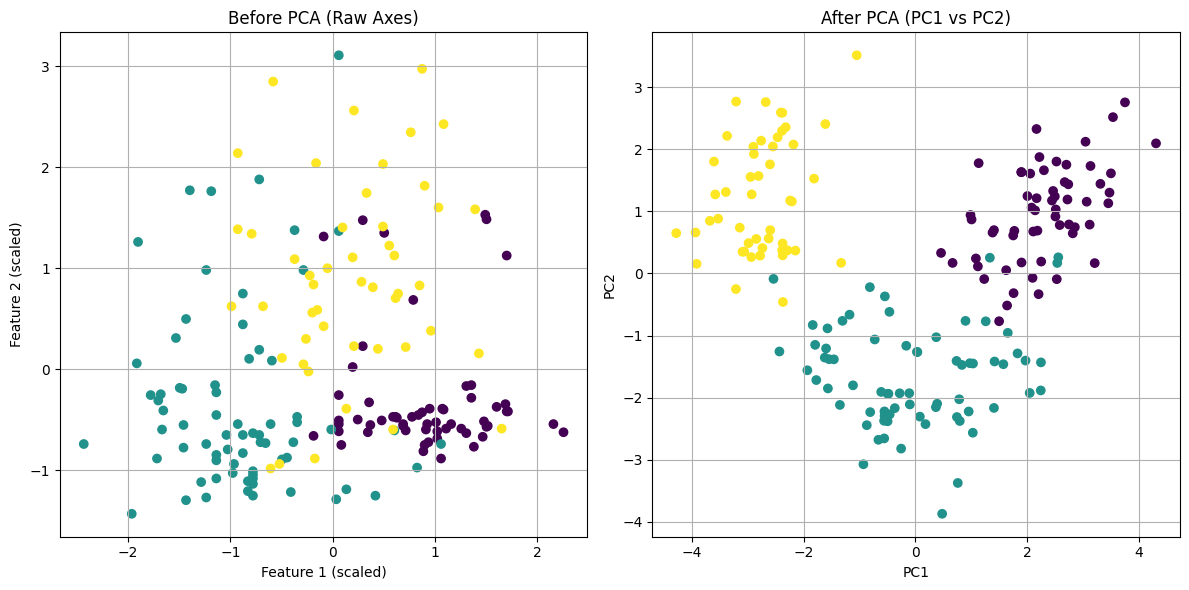

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Before PCA plot
axes[0].scatter(Z[:,0], Z[:,1], c=y, cmap='viridis')
axes[0].set_title("Before PCA (Raw Axes)")
axes[0].set_xlabel("Feature 1 (scaled)")
axes[0].set_ylabel("Feature 2 (scaled)")
axes[0].grid(True)

# After PCA plot
axes[1].scatter(Z_pca[:,0], Z_pca[:,1], c=y, cmap='viridis')
axes[1].set_title("After PCA (PC1 vs PC2)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].grid(True)

plt.tight_layout()
plt.show()

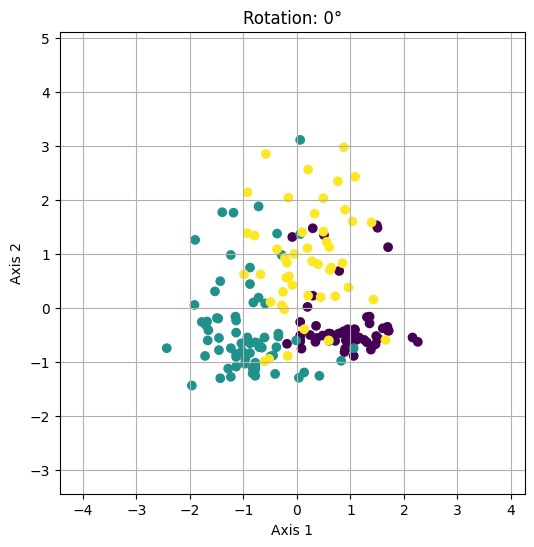

In [ ]:
# -----------------------------------------------
# 7. Rotation animation
# -----------------------------------------------
# We will rotate the dataset gradually from original axes to PC axes

fig, ax = plt.subplots(figsize=(6,6))

def rotate_points(theta):
    # rotation matrix
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    return Z[:, :2].dot(R.T)

# Initialize the scatter plot with actual data for the first frame
sc = ax.scatter(Z[:,0], Z[:,1], c=y, cmap='viridis')
ax.set_xlim(Z[:,0].min()-2, Z[:,0].max()+2)
ax.set_ylim(Z[:,1].min()-2, Z[:,1].max()+2)
ax.set_title("PCA Rotation Animation")
ax.set_xlabel("Axis 1")
ax.set_ylabel("Axis 2")
ax.grid(True)

# Define animation update
def update(frame):
    theta = np.deg2rad(frame)
    rotated = rotate_points(theta)
    sc.set_offsets(rotated)
    ax.set_title(f"Rotation: {frame}°")
    return sc,

anim = FuncAnimation(fig, update, frames=np.arange(0, 90, 2), interval=100)

# Render animation in notebook
HTML(anim.to_jshtml())

In [ ]:
# -----------------------------------------------
# 6. PCA from scratch (compute eigenvectors)
# -----------------------------------------------
cov_matrix = np.cov(Z.T)
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)

# Sort eigenvalues and eigenvectors
idx = eig_vals.argsort()[::-1]
eig_vals = eig_vals[idx]
eig_vecs = eig_vecs[:, idx]

# Projection matrix (first two PCs)
W = eig_vecs[:, :2]

# Final transformation
Z_pca_manual = Z.dot(W)

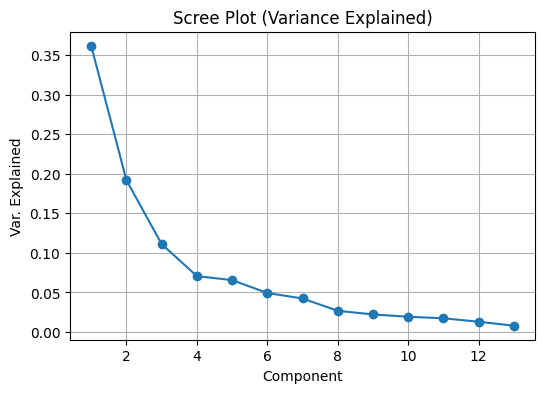

In [ ]:
# -----------------------------------------------
# 8. Scree plot
# -----------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(np.arange(1, len(eig_vals)+1), eig_vals / eig_vals.sum(), 'o-')
plt.title("Scree Plot (Variance Explained)")
plt.xlabel("Component")
plt.ylabel("Var. Explained")
plt.grid(True)
plt.show()



In [ ]:
# -----------------------------------------------
# 9. Loadings (Contributions of each variable)
# -----------------------------------------------
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=X.columns
)

loadings

,PC1,PC2
alcohol,0.144329,0.483652
malic_acid,-0.245188,0.224931
ash,-0.002051,0.316069
alcalinity_of_ash,-0.239320,-0.010591
magnesium,0.141992,0.299634
total_phenols,0.394661,0.065040
flavanoids,0.422934,-0.003360
nonflavanoid_phenols,-0.298533,0.028779
proanthocyanins,0.313429,0.039302
color_intensity,-0.088617,0.529996


### Selección de Cargas (Loadings)

Para seleccionar variables importantes, se identifican las características con las mayores cargas absolutas.
Estas cargas indican la contribución de cada variable a los componentes principales de interés.
Valores absolutos altos en las cargas significan una fuerte influencia de esa variable.
Así se determinan las variables más relevantes para interpretar cada componente.